# Notebook 04 — Índices Espectrales y Cambio Temporal (SNSM 2018→2024)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/miguepoloc/teledeteccion/blob/main/sesiones/sesion-02/colab/04_indices_espectrales_snsm.ipynb)

## Teledetección — Maestría en Ingeniería, Universidad del Magdalena
**Sesión 2 · Sábado 18 de julio de 2026**

---

### Índices que calcularemos hoy

| Índice | Fórmula (Sentinel-2) | Qué mide | Cuándo usarlo |
|--------|----------------------|----------|---------------|
| **NDVI** | (B8−B4)/(B8+B4) | Vigor general de la vegetación | Siempre, como base |
| **NDWI** | (B8−B11)/(B8+B11) | Contenido de agua en la vegetación | Estrés hídrico, riesgo Moniliasis |
| **NDRE** | (B8A−B5)/(B8A+B5) | Contenido de clorofila (Red Edge) | Estrés temprano, salud del cultivo |
| **SAVI** | 1.5×(B8−B4)/(B8+B4+0.5) | Vegetación con suelo expuesto | Cultivos jóvenes, zonas áridas |
| **EVI** | 2.5×(B8−B4)/(B8+6B4−7.5B2+1) | Vegetación muy densa | Bosque tropical, cacao adulto |
| **NDMI** | (B8A−B11)/(B8A+B11) | Humedad del dosel (dominado por SWIR) | Estrés hídrico, riesgo de incendio |
| **CLre** | (B7/B5) − 1 | Índice de clorofila en el borde rojo | Estimación de contenido de clorofila foliar |

### Objetivo del análisis temporal
Comparar el **NDVI de 2018 vs. 2024** en la zona cacaotera de la SNSM para detectar el cambio
de cobertura café → cacao que documenta el **Artículo 1** de investigación doctoral.

In [1]:
!pip install geemap --quiet

import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project='teledeteccion-miguepoloc')

# Zona de estudio
zona_snsm = ee.Geometry.Rectangle([-74.2, 10.5, -73.8, 11.0])

print("✓ Todo listo")

✓ Todo listo


---

## Paso 1 — Función maestra para calcular todos los índices

In [2]:
# ============================================================
# FUNCIÓN PARA CARGAR SENTINEL-2 Y CALCULAR TODOS LOS ÍNDICES
# ============================================================

def cargar_con_indices(fecha_inicio, fecha_fin):
    """
    Carga Sentinel-2 L2A, enmascara nubes y calcula:
    NDVI, NDWI, NDRE, SAVI, EVI, NDMI, CLre
    Retorna la imagen mediana del período con todos los índices como bandas.
    """

    def enmascarar_nubes(imagen):
        scl = imagen.select('SCL')
        mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
        return imagen.updateMask(mask)

    img = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(zona_snsm)
        .filterDate(fecha_inicio, fecha_fin)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
        .map(enmascarar_nubes)
        .median()
        .clip(zona_snsm)
    )

    # NDVI — Normalized Difference Vegetation Index
    # Mide vigor de la vegetación | Rango -1 a +1
    ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')

    # NDWI — Normalized Difference Water Index (Gao, 1996)
    # Mide contenido de agua en la vegetación | SWIR sensible al agua
    # Un NDWI alto = dosel muy húmedo → condiciones para Moniliasis (Artículo 2)
    ndwi = img.normalizedDifference(['B8', 'B11']).rename('NDWI')

    # NDRE — Normalized Difference Red Edge Index
    # Mide contenido de clorofila | Detecta estrés antes que el ojo humano
    # EXCLUSIVO de Sentinel-2 — Landsat NO tiene bandas Red Edge
    ndre = img.normalizedDifference(['B8A', 'B5']).rename('NDRE')

    # SAVI — Soil Adjusted Vegetation Index (Huete, 1988)
    # Corrige el efecto del suelo expuesto en el NDVI
    # L=0.5 es el factor de ajuste estándar
    savi = img.expression(
        '1.5 * (NIR - RED) / (NIR + RED + 0.5)',
        {'NIR': img.select('B8'), 'RED': img.select('B4')}
    ).rename('SAVI')

    # EVI — Enhanced Vegetation Index
    # No se satura en vegetación muy densa (limitación del NDVI)
    # Corrige efectos atmosféricos usando la banda azul
    evi = img.expression(
        '2.5 * (NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1)',
        {
            'NIR':  img.select('B8').divide(10000),
            'RED':  img.select('B4').divide(10000),
            'BLUE': img.select('B2').divide(10000)
        }
    ).rename('EVI')

    # NDMI — Normalized Difference Moisture Index
    # Usa B8A (NIR estrecho) y B11 (SWIR) en vez de B8 y B11 (como el NDWI)
    # Más sensible a la humedad del dosel que el NDWI clásico
    ndmi = img.normalizedDifference(['B8A', 'B11']).rename('NDMI')

    # CLre — Chlorophyll Index Red Edge
    # Razón entre dos bandas Red Edge (B7 y B5), no una diferencia normalizada
    # Sensible a concentraciones altas de clorofila donde el NDVI ya está saturado
    clre = img.expression(
        '(REDGE3 / REDGE1) - 1',
        {'REDGE3': img.select('B7'), 'REDGE1': img.select('B5')}
    ).rename('CLre')

    return img.addBands([ndvi, ndwi, ndre, savi, evi, ndmi, clre])


# Cargar imágenes para dos años en temporada seca (misma época para comparar)
print("Cargando imagen 2024 (ene–mar)...")
imagen_2024 = cargar_con_indices('2024-01-01', '2024-03-31')

print("Cargando imagen 2018 (ene–mar)...")
imagen_2018 = cargar_con_indices('2018-01-01', '2018-03-31')

print("\n✓ Imágenes listas con todos los índices")
print("Bandas disponibles:", imagen_2024.bandNames().getInfo())

Cargando imagen 2024 (ene–mar)...
Cargando imagen 2018 (ene–mar)...

✓ Imágenes listas con todos los índices
Bandas disponibles: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE', 'NDVI', 'NDWI', 'NDRE', 'SAVI', 'EVI', 'NDMI', 'CLre']


---

## Paso 2 — Comparar todos los índices visualmente

In [3]:
# ============================================================
# MAPA INTERACTIVO — TODOS LOS ÍNDICES (2024)
# ============================================================

paleta_vegetacion = ['#d73027', '#f46d43', '#fdae61', '#ffffbf', '#a6d96a', '#1a9641']
paleta_agua       = ['#d7191c', '#fdae61', '#ffffbf', '#abdda4', '#2b83ba']
paleta_clorofila  = ['#ffffcc', '#c2e699', '#78c679', '#31a354', '#006837']

mapa = geemap.Map()
mapa.centerObject(zona_snsm, zoom=11)

# Color natural (referencia)
mapa.addLayer(imagen_2024, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000, 'gamma': 1.4}, 'Color Natural', False)

# NDVI
mapa.addLayer(imagen_2024.select('NDVI'),  {'min': -0.1, 'max': 0.9,  'palette': paleta_vegetacion}, 'NDVI (vigor)')

# NDWI
mapa.addLayer(imagen_2024.select('NDWI'),  {'min': -0.5, 'max': 0.5,  'palette': paleta_agua},       'NDWI (agua en vegetación)', False)

# NDRE
mapa.addLayer(imagen_2024.select('NDRE'),  {'min': 0,    'max': 0.5,  'palette': paleta_clorofila},  'NDRE (clorofila)', False)

# SAVI
mapa.addLayer(imagen_2024.select('SAVI'),  {'min': -0.1, 'max': 0.7,  'palette': paleta_vegetacion}, 'SAVI (suelo ajustado)', False)

# EVI
mapa.addLayer(imagen_2024.select('EVI'),   {'min': 0,    'max': 0.8,  'palette': paleta_vegetacion}, 'EVI (vegetación densa)', False)

# NDMI
mapa.addLayer(imagen_2024.select('NDMI'),  {'min': -0.5, 'max': 0.5,  'palette': paleta_agua},       'NDMI (humedad del dosel)', False)

# CLre
mapa.addLayer(imagen_2024.select('CLre'),  {'min': 0,    'max': 3,    'palette': paleta_clorofila},  'CLre (clorofila red edge)', False)

mapa

Map(center=[10.749994930545569, -73.99999999999935], controls=(WidgetControl(options=['position', 'transparent…

**Activa cada índice uno por uno** y responde:
- ¿Dónde es alto el NDWI? ¿Coincide con zonas de alta precipitación o riego?
- ¿El NDRE muestra los mismos patrones que el NDVI o hay diferencias?
- ¿Dónde el SAVI es diferente del NDVI? (busca zonas con suelo visible)

---

## Paso 3 — Análisis estadístico comparativo de índices

In [4]:
# ============================================================
# TABLA COMPARATIVA: estadísticas de todos los índices
# ============================================================

indices = ['NDVI', 'NDWI', 'NDRE', 'SAVI', 'EVI', 'NDMI', 'CLre']

def obtener_stats(imagen, lista_indices):
    """Calcula media y desviación estándar de cada índice."""
    resultados = {}
    for idx in lista_indices:
        stats = imagen.select(idx).reduceRegion(
            reducer=ee.Reducer.mean().combine(ee.Reducer.stdDev(), None, True),
            geometry=zona_snsm,
            scale=20,
            maxPixels=1e9
        ).getInfo()
        resultados[idx] = {
            'media': round(stats.get(f'{idx}_mean', 0) or 0, 4),
            'std':   round(stats.get(f'{idx}_stdDev', 0) or 0, 4)
        }
    return resultados

print("Calculando estadísticas 2024...")
stats_2024 = obtener_stats(imagen_2024, indices)

print("Calculando estadísticas 2018...")
stats_2018 = obtener_stats(imagen_2018, indices)

# Mostrar tabla comparativa
print("\n" + "=" * 65)
print(f"{'Índice':<8} {'2024 Media':>12} {'2024 Std':>10} {'2018 Media':>12} {'2018 Std':>10} {'Cambio':>8}")
print("=" * 65)
for idx in indices:
    m24 = stats_2024[idx]['media']
    s24 = stats_2024[idx]['std']
    m18 = stats_2018[idx]['media']
    s18 = stats_2018[idx]['std']
    cambio = round(m24 - m18, 4)
    signo = '+' if cambio > 0 else ''
    print(f"{idx:<8} {m24:>12.4f} {s24:>10.4f} {m18:>12.4f} {s18:>10.4f} {signo+str(cambio):>8}")
print("=" * 65)
print("Cambio positivo = aumento entre 2018 y 2024")

Calculando estadísticas 2024...
Calculando estadísticas 2018...

Índice     2024 Media   2024 Std   2018 Media   2018 Std   Cambio
NDVI           0.7404     0.1700       0.7449     0.1764  -0.0045
NDWI           0.2084     0.1879       0.2235     0.1831  -0.0151
NDRE           0.5364     0.1286       0.5439     0.1363  -0.0075
SAVI           1.1104     0.2550       1.1172     0.2646  -0.0068
EVI            0.5102     0.1637       0.5276     0.1705  -0.0174
NDMI           0.2446     0.1794       0.2536     0.1761   -0.009
CLre           2.2508     1.0192       2.3863     1.1672  -0.1355
Cambio positivo = aumento entre 2018 y 2024


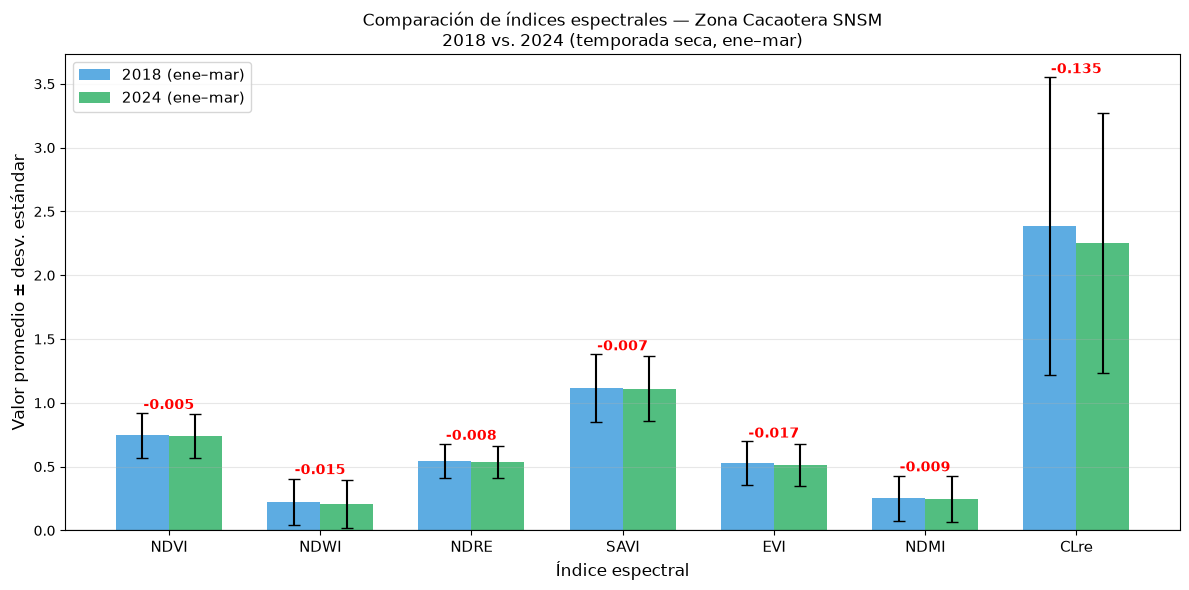

✓ Gráfico guardado


In [5]:
# ============================================================
# GRÁFICO: Comparación de índices 2018 vs 2024
# ============================================================

medias_2024 = [stats_2024[i]['media'] for i in indices]
medias_2018 = [stats_2018[i]['media'] for i in indices]
stds_2024   = [stats_2024[i]['std']   for i in indices]
stds_2018   = [stats_2018[i]['std']   for i in indices]

x = np.arange(len(indices))
ancho = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

barras_2018 = ax.bar(x - ancho/2, medias_2018, ancho, label='2018 (ene–mar)',
                     color='#3498db', alpha=0.8, yerr=stds_2018, capsize=4,
                     error_kw={'linewidth': 1.5})
barras_2024 = ax.bar(x + ancho/2, medias_2024, ancho, label='2024 (ene–mar)',
                     color='#27ae60', alpha=0.8, yerr=stds_2024, capsize=4,
                     error_kw={'linewidth': 1.5})

ax.set_xlabel('Índice espectral', fontsize=12)
ax.set_ylabel('Valor promedio ± desv. estándar', fontsize=12)
ax.set_title('Comparación de índices espectrales — Zona Cacaotera SNSM\n2018 vs. 2024 (temporada seca, ene–mar)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(indices, fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(0, color='black', linewidth=0.8)

# Anotar el cambio sobre cada par de barras
for i, idx in enumerate(indices):
    cambio = medias_2024[i] - medias_2018[i]
    signo = '+' if cambio >= 0 else ''
    color = 'green' if cambio >= 0 else 'red'
    y_max = max(medias_2024[i], medias_2018[i]) + max(stds_2024[i], stds_2018[i]) + 0.03
    ax.annotate(f'{signo}{cambio:.3f}', xy=(x[i], y_max), ha='center',
                fontsize=10, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('indices_2018_vs_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado")

### **Análisis de Resultados: Comparación de Índices Espectrales (2018 vs. 2024)**

Para explicar este gráfico y la tabla estadística, podemos estructurar la interpretación en tres conceptos clave:

#### **1. ¿Qué significan estos Índices Espectrales y qué miden?**
* **NDVI (Vigor de la Vegetación):** Es el índice general de salud y densidad foliar. Valores alrededor de **0.74** reflejan una vegetación muy densa y sana (bosques y cultivos bajo sombrío).
* **NDWI y NDMI (Humedad de la Vegetación):** Miden el contenido de agua líquida en el dosel de las hojas. Valores más altos indican hojas más hidratadas y con menor estrés por sequía.
* **NDRE y CLre (Clorofila en el Borde Rojo / Red Edge):** Son índices muy sensibles que estiman el contenido de clorofila. A diferencia del NDVI, **no se saturan** cuando la vegetación es extremadamente densa (como en la selva húmeda tropical de la SNSM), permitiendo ver pequeños cambios de vigor.
* **SAVI y EVI (Índices Optimizados):** Corrigen los efectos del suelo expuesto y de la atmósfera para dar mediciones más puras en zonas heterogéneas.

#### **2. Análisis del Cambio entre 2018 y 2024 (¿Qué nos dicen los datos?)**
Al observar las barras del gráfico y los valores de la tabla, vemos que **todos los índices disminuyeron levemente en 2024 en comparación con 2018** (todos los valores de "Cambio" en el gráfico son negativos):
* El **NDVI** cayó ligeramente un **-0.005** (de 0.745 a 0.740).
* El **NDWI** (agua en las hojas) bajó un **-0.015** (de 0.224 a 0.208).
* El **CLre** (clorofila foliar) sufrió el mayor descenso absoluto con un **-0.136** (de 2.386 a 2.251).

#### **3. ¿Cómo interpretar estos cambios climatológicamente?**
* **¿Es una catástrofe o deforestación? No.** La disminución es sumamente pequeña (por ejemplo, el NDVI apenas varió un 0.6%). La Sierra Nevada sigue estando muy verde y densa.
* **¿A qué se debe la bajada?** La explicación principal es la **variabilidad climática estacional**. La temporada seca (enero–marzo) de 2024 estuvo fuertemente influenciada por un **Fenómeno de El Niño severo**, lo que provocó:
  1. **Estrés Hídrico (Menos agua):** La caída en el NDWI y NDMI confirma que las hojas contenían menos agua y estaban bajo mayor estrés por la sequía.
  2. **Menos Clorofila Activa:** La caída en el CLre y NDRE muestra que la falta de agua causó que las plantas redujeran su contenido foliar de clorofila o entraran en un estado de letargo temporal para conservar recursos.
  3. **Leve pérdida de vigor general:** Al haber menor humedad y menor fotosíntesis activa, el vigor general medido por el NDVI y EVI se redujo sutilmente.

---

## Paso 4 — Mapa de cambio NDVI (2018 → 2024)

In [6]:
# ============================================================
# MAPA DE CAMBIO NDVI: 2024 - 2018
# ============================================================
# Interpretación:
#   Verde oscuro (positivo) = aumento de vegetación 2018→2024
#     → posible: reforestación, nuevas siembras de cacao, recuperación
#   Rojo (negativo) = pérdida de vegetación
#     → posible: deforestación, estrés prolongado, cambio a pasturas
#   Blanco (cercano a 0) = sin cambio significativo

cambio_ndvi = imagen_2024.select('NDVI').subtract(imagen_2018.select('NDVI')).rename('Cambio_NDVI')

# Clasificar el cambio en categorías
cambio_categorizado = (
    cambio_ndvi
    .where(cambio_ndvi.lt(-0.2),  1)  # pérdida significativa (>0.2)
    .where(cambio_ndvi.gte(-0.2).And(cambio_ndvi.lt(-0.1)), 2)  # pérdida moderada
    .where(cambio_ndvi.gte(-0.1).And(cambio_ndvi.lt(0.1)),  3)  # sin cambio
    .where(cambio_ndvi.gte(0.1).And(cambio_ndvi.lt(0.2)),   4)  # ganancia moderada
    .where(cambio_ndvi.gte(0.2),  5)   # ganancia significativa
    .rename('Cambio_Categorizado')
)

# Área por categoría de cambio
area_total = zona_snsm.area().divide(1e6)  # km²
print(f"Área total de análisis: {area_total.getInfo():.1f} km²")

mapa2 = geemap.Map()
mapa2.centerObject(zona_snsm, zoom=11)

# Color natural 2024 como fondo
mapa2.addLayer(
    imagen_2024,
    {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000, 'gamma': 1.4},
    'Color Natural 2024',
    False
)

# NDVI 2018 (para comparar)
mapa2.addLayer(
    imagen_2018.select('NDVI'),
    {'min': -0.1, 'max': 0.9, 'palette': paleta_vegetacion},
    'NDVI 2018',
    False
)

# NDVI 2024
mapa2.addLayer(
    imagen_2024.select('NDVI'),
    {'min': -0.1, 'max': 0.9, 'palette': paleta_vegetacion},
    'NDVI 2024',
    False
)

# Cambio continuo (gradiente)
mapa2.addLayer(
    cambio_ndvi,
    {'min': -0.3, 'max': 0.3, 'palette': ['#d73027', '#fc8d59', '#ffffff', '#91bfdb', '#1a9641']},
    'Cambio NDVI 2018→2024 (rojo=pérdida, verde=ganancia)'
)

# Cambio categorizado
mapa2.addLayer(
    cambio_categorizado,
    {'min': 1, 'max': 5, 'palette': ['#d73027', '#fc8d59', '#ffffbf', '#91bfdb', '#1a9641']},
    'Cambio categorizado',
    False
)

mapa2

Área total de análisis: 2429.5 km²


Map(center=[10.749994930545569, -73.99999999999935], controls=(WidgetControl(options=['position', 'transparent…

---

## Paso 5 — Exportar resultados a Google Drive

In [7]:
# ============================================================
# EXPORTAR IMÁGENES A GOOGLE DRIVE
# ============================================================
# Los archivos exportados pueden abrirse en QGIS o SNAP

# Los exports corren en segundo plano en GEE
# Ve a Tasks (panel derecho del Code Editor) o revisa tu Google Drive

# Exportar NDVI 2024
task_ndvi_2024 = ee.batch.Export.image.toDrive(
    image=imagen_2024.select('NDVI'),
    description='NDVI_SNSM_2024_ene_mar',
    folder='Teledeteccion_Maestria',   # carpeta en tu Google Drive
    fileNamePrefix='NDVI_SNSM_2024',
    region=zona_snsm,
    scale=10,                          # resolución 10 m (igual que Sentinel-2)
    crs='EPSG:4326',                   # WGS84
    maxPixels=1e9
)

# Exportar mapa de cambio
task_cambio = ee.batch.Export.image.toDrive(
    image=cambio_ndvi,
    description='Cambio_NDVI_2018_2024',
    folder='Teledeteccion_Maestria',
    fileNamePrefix='Cambio_NDVI_2018_vs_2024',
    region=zona_snsm,
    scale=10,
    crs='EPSG:4326',
    maxPixels=1e9
)

# Iniciar las tareas de exportación
task_ndvi_2024.start()
task_cambio.start()

print("✓ Tareas de exportación iniciadas")
print("  Los archivos aparecerán en tu Google Drive → carpeta 'Teledeteccion_Maestria'")
print("  Puede tardar 5–15 minutos según el tamaño del área")
print()
print("Para abrir en QGIS:")
print("  1. Descarga el .tif desde Google Drive")
print("  2. En QGIS: Layer → Add Layer → Add Raster Layer")
print("  3. Aplica una paleta de colores divergente (rojo-blanco-verde para el cambio)")

✓ Tareas de exportación iniciadas
  Los archivos aparecerán en tu Google Drive → carpeta 'Teledeteccion_Maestria'
  Puede tardar 5–15 minutos según el tamaño del área

Para abrir en QGIS:
  1. Descarga el .tif desde Google Drive
  2. En QGIS: Layer → Add Layer → Add Raster Layer
  3. Aplica una paleta de colores divergente (rojo-blanco-verde para el cambio)


---

## Paso 6 — Interpretación: ¿Qué nos dice el cambio NDVI?

Conectamos los resultados con el contexto del Artículo 1 de investigación.

In [8]:
# ============================================================
# ANÁLISIS DEL CAMBIO POR FRANJA ALTITUDINAL
# ============================================================

dem = ee.Image('USGS/SRTMGL1_003')

franjas = {
    'Franja Baja (400–700m) — Cacao':   dem.gte(400).And(dem.lt(700)),
    'Franja Media (700–1200m) — Transición': dem.gte(700).And(dem.lt(1200)),
    'Franja Alta (1200–1800m) — Café':   dem.gte(1200).And(dem.lte(1800)),
}

print("=" * 70)
print("CAMBIO NDVI 2018→2024 POR FRANJA ALTITUDINAL — SNSM")
print("=" * 70)

resultados_cambio = []

for nombre, mascara in franjas.items():
    stats = cambio_ndvi.updateMask(mascara).reduceRegion(
        reducer=ee.Reducer.mean().combine(ee.Reducer.stdDev(), None, True),
        geometry=zona_snsm,
        scale=20,
        maxPixels=1e9
    ).getInfo()

    media = stats.get('Cambio_NDVI_mean', 0) or 0
    std   = stats.get('Cambio_NDVI_stdDev', 0) or 0

    tendencia = '↑ AUMENTO' if media > 0.05 else ('↓ PÉRDIDA' if media < -0.05 else '→ ESTABLE')

    print(f"\n{nombre}")
    print(f"  Cambio promedio: {media:+.4f} ± {std:.4f}")
    print(f"  Tendencia: {tendencia}")

    resultados_cambio.append({'franja': nombre.split(' — ')[0], 'media': media, 'std': std})

print("\n" + "=" * 70)
print("INTERPRETACIÓN:")
print("  Franja Baja: si NDVI aumentó → el cacao adulto ganó densidad de dosel")
print("  Franja Media: si NDVI aumentó → posible expansión del cacao desde la zona baja")
print("  Franja Alta: si NDVI disminuyó → posible abandono del café o cambio de uso")
print("  Estos patrones son el núcleo del Artículo 1 de investigación doctoral.")

CAMBIO NDVI 2018→2024 POR FRANJA ALTITUDINAL — SNSM

Franja Baja (400–700m) — Cacao
  Cambio promedio: -0.0128 ± 0.0876
  Tendencia: → ESTABLE

Franja Media (700–1200m) — Transición
  Cambio promedio: -0.0173 ± 0.0760
  Tendencia: → ESTABLE

Franja Alta (1200–1800m) — Café
  Cambio promedio: -0.0115 ± 0.0777
  Tendencia: → ESTABLE

INTERPRETACIÓN:
  Franja Baja: si NDVI aumentó → el cacao adulto ganó densidad de dosel
  Franja Media: si NDVI aumentó → posible expansión del cacao desde la zona baja
  Franja Alta: si NDVI disminuyó → posible abandono del café o cambio de uso
  Estos patrones son el núcleo del Artículo 1 de investigación doctoral.


---

## ✅ Resumen completo de la Sesión 2

### Notebooks completados hoy

| Notebook | Tema | Estado |
|----------|------|--------|
| 00 | Python desde cero: variables, listas, matplotlib | ✅ |
| 01 | GEE: autenticación, cargar Sentinel-2, visualizar | ✅ |
| 02 | NDVI satelital: rasterio local + GEE | ✅ |
| 03 | NDVI con shapefiles: análisis por franja altitudinal | ✅ |
| 04 | Todos los índices + cambio temporal 2018→2024 | ✅ |

### Herramientas dominadas
- **Python** + NumPy + Matplotlib
- **Google Earth Engine** API Python (`ee`)
- **geemap** para mapas interactivos
- **rasterio** para archivos locales

### Índices aprendidos

| Índice | Fórmula Sentinel-2 | Uso principal |
|--------|---------------------|---------------|
| NDVI | (B8−B4)/(B8+B4) | Salud general de la vegetación |
| NDWI | (B8−B11)/(B8+B11) | Agua en el dosel → riesgo Moniliasis |
| NDRE | (B8A−B5)/(B8A+B5) | Clorofila, estrés temprano |
| SAVI | 1.5×(B8−B4)/(B8+B4+0.5) | Cultivos jóvenes con suelo expuesto |
| EVI | 2.5×(B8−B4)/(B8+6B4−7.5B2+1) | Bosque/cacao denso sin saturación |
| NDMI | (B8A−B11)/(B8A+B11) | Humedad del dosel, más sensible que NDWI |
| CLre | (B7/B5)−1 | Clorofila donde el NDVI ya está saturado |

---

### Tarea para casa

1. **Modificar la fecha** de la imagen 2024 por octubre–noviembre 2024 (temporada húmeda):
   - ¿Cuántos píxeles quedan válidos (sin nubes)?
   - ¿Cambia el NDVI entre temporada seca y húmeda?

2. **Calcular NDWI** para 2018 y compararlo con el de 2024:
   - ¿En qué franja altitudinal cambió más el contenido de agua en la vegetación?

3. **Si ya tienes SNAP funcionando:** calcula NDWI y SAVI ahí mismo con Band Math (ver
   `snap/guia_snap_paso_a_paso.md`, Paso 6). **Si SNAP aún no te funciona:** hazlo en este
   Notebook 04, ya tienes NDWI, SAVI, NDMI y CLre calculados arriba — solo repite el
   análisis para 2018 y compáralo con 2024.

---
*Notebook elaborado para el curso de Teledetección — Maestría en Ingeniería, Universidad del Magdalena.*
*Miguel Ángel Polo Castañeda*